In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import ScalarFormatter
plt.rcParams['axes.ticklabel_format'] = 'sci'


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

KeyError: 'axes.ticklabel_format is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

In [ ]:
k = 1e3/1023 #mkm/del
sigma_k = k * (1/1e4 + 1/1023**2) ** 0.5
center = 374.5 #del
sigma_center = 0.5 #del
r_spot = (419 - 330) * k / 2 #mkm
sigma_r_spot = (419 - 330) * sigma_k / 2 + 2 * k #mkm
k, sigma_k
r_spot, sigma_r_spot

(43.499511241446726, 2.3921026598876254)

In [99]:
data = pd.read_excel("измерения.xlsx", sheet_name="желтый_темные_светлые").dropna()
data['n, номер кольца'] = data['n, номер кольца'].astype(int)
diameters = pd.DataFrame()
diameters.insert(0, 'n', range(1, 18))

dark_D_min = []
for i in range(len(diameters)):
    n_value = diameters.loc[i, 'n']
    
    dark_r_right = data.loc[data['n, номер кольца'] == n_value, 'dark r_min, дел'].iloc[0]
    dark_r_left = data.loc[data['n, номер кольца'] == -n_value, 'dark r_max, дел'].iloc[0]
    
    dark_D_min.append(dark_r_right - dark_r_left)

diameters['dark_D_min'] = dark_D_min 
diameters['dark_D_min'] = diameters['dark_D_min'] * k
diameters['sigma_dark_D_min'] = ((sigma_k)**2 + k**2/diameters['dark_D_min']**2)**0.5 * diameters['dark_D_min']#mkm

dark_D_max = []
for i in range(len(diameters)):
    n_value = diameters.loc[i, 'n']
    
    dark_r_right = data.loc[data['n, номер кольца'] == n_value, 'dark r_max, дел'].iloc[0]
    dark_r_left = data.loc[data['n, номер кольца'] == -n_value, 'dark r_min, дел'].iloc[0]
    
    dark_D_max.append(dark_r_right - dark_r_left)

diameters['dark_D_max'] = dark_D_max
diameters['dark_D_max'] = diameters['dark_D_max'] * k
diameters['sigma_dark_D_max'] = ((sigma_k)**2 + k/diameters['dark_D_max']**2)**0.5 * diameters['dark_D_max']#mkm

light_D_min = []
for i in range(len(diameters)):
    n_value = diameters.loc[i, 'n']
    
    light_r_right = data.loc[data['n, номер кольца'] == n_value, 'light r_min, дел'].iloc[0]
    light_r_left = data.loc[data['n, номер кольца'] == -n_value, 'light r_max, дел'].iloc[0]
    
    light_D_min.append(light_r_right - light_r_left)

diameters['light_D_min'] = light_D_min
diameters['light_D_min'] = diameters['light_D_min'] * k
diameters['sigma_light_D_min'] = ((sigma_k)**2 + k/diameters['light_D_min']**2)**0.5 * diameters['light_D_min']#mkm

light_D_max = []
for i in range(len(diameters)):
    n_value = diameters.loc[i, 'n']
    
    light_r_right = data.loc[data['n, номер кольца'] == n_value, 'light r_max, дел'].iloc[0]
    light_r_left = data.loc[data['n, номер кольца'] == -n_value, 'light r_min, дел'].iloc[0]
    
    light_D_max.append(light_r_right - light_r_left)

diameters['light_D_max'] = light_D_max
diameters['light_D_max'] = diameters['light_D_max'] * k
diameters['sigma_light_D_max'] = ((sigma_k)**2 + k/diameters['light_D_max']**2)**0.5 * diameters['dark_D_max']#mkm

diameters['dark_D'] = (diameters['dark_D_min'] + diameters['dark_D_max'])/2
diameters['sigma_dark_D'] = (((diameters['dark_D_min'] - diameters['dark_D_max'])/2/diameters['dark_D'])**2 +
                             (diameters['sigma_dark_D_min'] + diameters['sigma_dark_D_max'])**2/diameters['dark_D']**2)**0.5 * diameters['dark_D']
diameters['light_D'] = (diameters['light_D_min'] + diameters['light_D_max'])/2
diameters['sigma_light_D'] = (((diameters['light_D_min'] - diameters['light_D_max'])/2/diameters['light_D'])**2 +
                             (diameters['sigma_light_D_min'] + diameters['sigma_light_D_max'])**2/diameters['light_D']**2)**0.5 * diameters['light_D']
diameters.to_excel("diameters.xlsx")

In [80]:
k_dark, b_dark = np.polyfit(diameters["n"].iloc[:12], (diameters["dark_D"]/2).iloc[:12]**2/1e6, 1)
sigma_k_dark = k_dark * np.average(diameters['sigma_dark_D'] / diameters['dark_D'])
sigma_b_dark = b_dark * np.average(diameters['sigma_dark_D'] / diameters['dark_D'])

k_light, b_light = np.polyfit(diameters["n"].iloc[:12], (diameters["light_D"]/2).iloc[:12]**2/1e6, 1)
sigma_k_light = k_light * np.average(diameters['sigma_light_D'] / diameters['light_D'])
sigma_b_light = -b_light * np.average(diameters['sigma_light_D'] / diameters['light_D'])
n_th = np.linspace(0, 18)

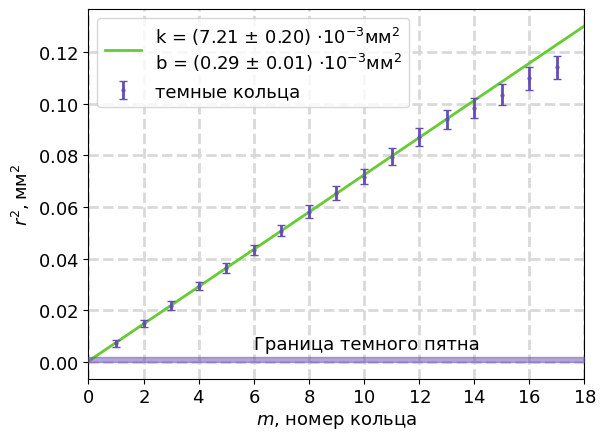

In [98]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)

plt.plot(n_th, k_dark * n_th + b_dark, c = light_green,  
         label = (f'k = ({k_dark * 1e3:.2f} ' + r'$\pm$' + f' {sigma_k_dark * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_dark * 1e3:.2f} ' + r'$\pm$' + f' {sigma_b_dark * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(diameters["n"], (diameters["dark_D"]/2)**2/1e6, 
             yerr = diameters["dark_D"] * diameters["sigma_dark_D"]/2e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'темные кольца',
             color = dark_purple,
             zorder = 5)
plt.fill_between([0, 18], [0, 0], [r_spot**2/1e6, r_spot**2/1e6], color = dark_purple, alpha = 0.5, zorder = 10)
plt.text(6, 0.005, "Граница темного пятна")
plt.ylabel(r'$r^2, \text{мм}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.xlim(0, 18)
plt.legend()
plt.savefig('images/dark.png', dpi = 300)

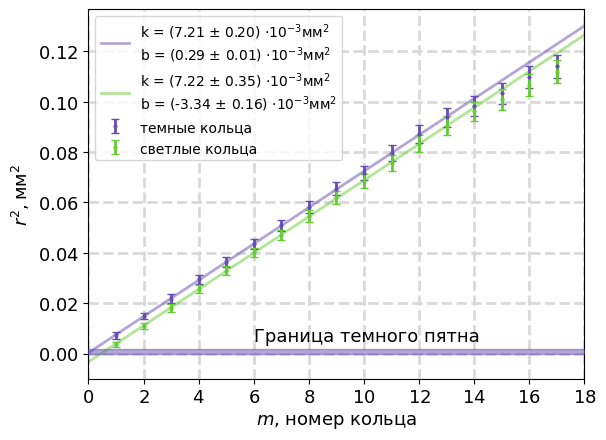

In [96]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)

plt.plot(n_th, k_dark * n_th + b_dark, c = dark_purple, alpha = 0.5, 
         label = (f'k = ({k_dark * 1e3:.2f} ' + r'$\pm$' + f' {sigma_k_dark * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_dark * 1e3:.2f} ' + r'$\pm$' + f' {sigma_b_dark * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(diameters["n"], (diameters["dark_D"]/2)**2/1e6, 
             yerr = diameters["dark_D"] * diameters["sigma_dark_D"]/2e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'темные кольца',
             color = dark_purple,
             zorder = 5)

plt.plot(n_th, k_light * n_th + b_light, c = light_green, alpha = 0.5, 
         label = (f'k = ({k_light * 1e3:.2f} ' + r'$\pm$' + f' {sigma_k_light * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_light * 1e3:.2f} ' + r'$\pm$' + f' {sigma_b_light * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(diameters["n"], (diameters["light_D"]/2)**2/1e6, 
             yerr = diameters["light_D"] * diameters["sigma_dark_D"]/2e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'светлые кольца',
             color = light_green,
             zorder = 5)

plt.fill_between([0, 18], [0, 0], [r_spot**2/1e6, r_spot**2/1e6], color = dark_purple, alpha = 0.5, zorder = 10)
plt.text(6, 0.005, "Граница темного пятна")
plt.ylabel(r'$r^2, \text{мм}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.xlim(0, 18)
plt.legend(loc = 'upper left', prop={'size': 10})
plt.savefig('images/dark and light.png', dpi = 300)

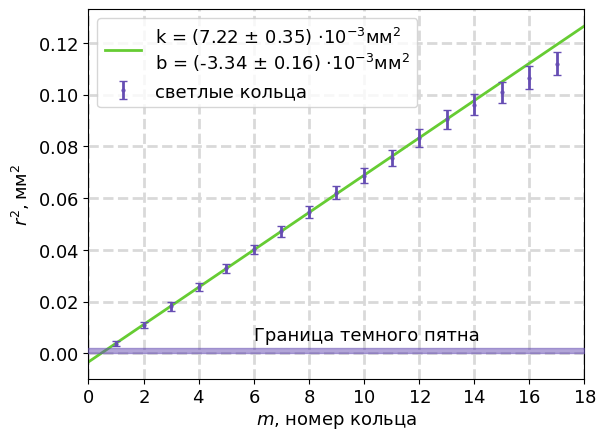

In [84]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2, zorder = 0)

plt.plot(n_th, k_light * n_th + b_light, c = light_green, 
         label = (f'k = ({k_light * 1e3:.2f} ' + r'$\pm$' + f' {sigma_k_light * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$' + "\n"
                  f'b = ({b_light * 1e3:.2f} ' + r'$\pm$' + f' {sigma_b_light * 1e3:.2f}) ' + r'$\cdot 10^{-3}\text{мм}^2$'))
plt.errorbar(diameters["n"], (diameters["light_D"]/2)**2/1e6, 
             yerr = diameters["light_D"] * diameters["sigma_dark_D"]/2e6, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'светлые кольца',
             color = dark_purple,
             zorder = 5)
plt.fill_between([0, 18], [0, 0], [r_spot**2/1e6, r_spot**2/1e6], color = dark_purple, alpha = 0.5, zorder = 10)
plt.text(6, 0.005, "Граница темного пятна")
plt.ylabel(r'$r^2, \text{мм}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.xlim(0, 18)
plt.legend()
plt.savefig('images/light.png', dpi = 300)

In [17]:
backlash = pd.read_excel("измерения.xlsx", sheet_name="люфт")[["n", "left_outer", "left_inner", "right_inner", "right_outer"]].dropna()
backlash["n"] = backlash["n"].astype(int)
backlash['left'] = (backlash['left_outer'] + backlash['left_inner'])/2
backlash['sigma_left'] = (backlash['left_outer'] - backlash['left_inner'])/2
backlash['right'] = (backlash['right_outer'] + backlash['right_inner'])/2
backlash['sigma_right'] = (backlash['right_outer'] - backlash['right_inner'])/2

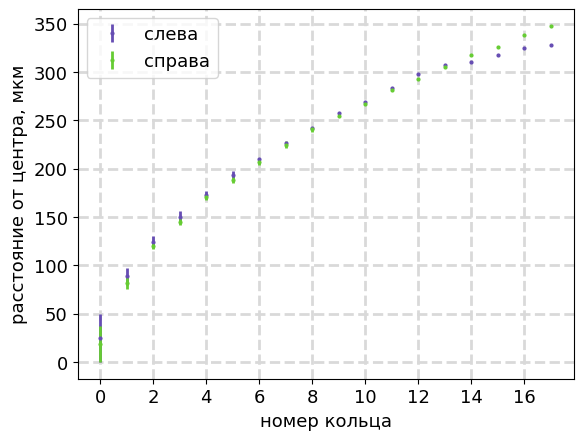

In [29]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.errorbar(backlash["n"], backlash['left'] * k, 
             yerr = backlash["sigma_left"] * k, 
             fmt = 'o',  
             markersize = 2, 
             label = 'слева',
             color = dark_purple)

#plt.fill_between(backlash["n"], backlash["left_inner"] * k, backlash["left_outer"] * k, color = dark_purple, alpha = 0.5)
plt.errorbar(backlash["n"], backlash['right'] * k, 
             yerr = backlash["sigma_right"] * k, 
             fmt = 'o',  
             markersize = 2, 
             label = 'справа',
             color = light_green)
#plt.fill_between(backlash["n"], backlash["right_inner"] * k, backlash["right_outer"] * k, color = dark_purple, alpha = 0.5)



plt.gca().xaxis.set_major_locator(MultipleLocator(2))  
plt.legend()
plt.xlabel("номер кольца")
plt.ylabel("расстояние от центра, мкм")
plt.savefig('images/backlash.png', dpi = 300)

In [100]:
lambda_y = 578 * 1e-6
k_avg = (k_dark + k_light) / 2
sigma_k_avg = (sigma_k_dark + sigma_k_light) / 2
k_avg/lambda_y, sigma_k_avg/lambda_y

(12.48242890376592, 0.47841475330511335)